# Seaborn Revision Notebook
 
 Seaborn and Matplotlib are used here. Seaborn creates the charts, and Matplotlib is used for figure size, titles, labels, and display.

## Charts Covered
 
 Count plot, bar plot, histogram, KDE plot, box plot, violin plot, strip plot, swarm plot, scatter plot, line plot, regression plot, heatmap, pair plot, joint plot, and categorical plot.

## 1. Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
sns.set_theme(style="whitegrid")

In [5]:
df = pd.read_csv("Cleaned_Tatanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [6]:
# Quick check of rows, columns, and missing values.
print(df.shape)
print(df.columns)
df.isnull().sum()

(418, 11)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 2. Useful Seaborn Pattern

Most Seaborn charts follow this pattern:

```python
plt.figure(figsize=(8, 5))
sns.plot_name(data=df, x="column1", y="column2")
plt.title("Chart Title")
plt.show()
```

## 3. Count Plot

Use a count plot to count values in a category column.

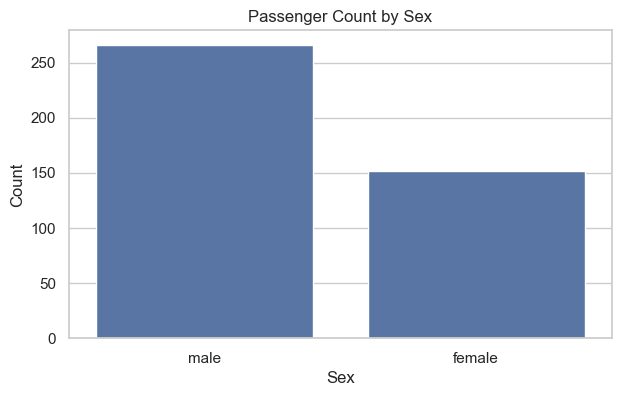

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Sex")
plt.title("Passenger Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

## 4. Bar Plot

Use a bar plot to compare an average numeric value across categories.

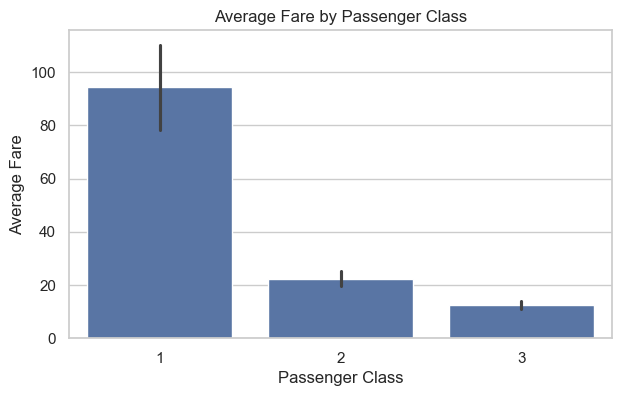

In [8]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="Pclass", y="Fare", estimator="mean")
plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")
plt.show()

## 5. Histogram

Use a histogram to see the distribution of one numeric column.

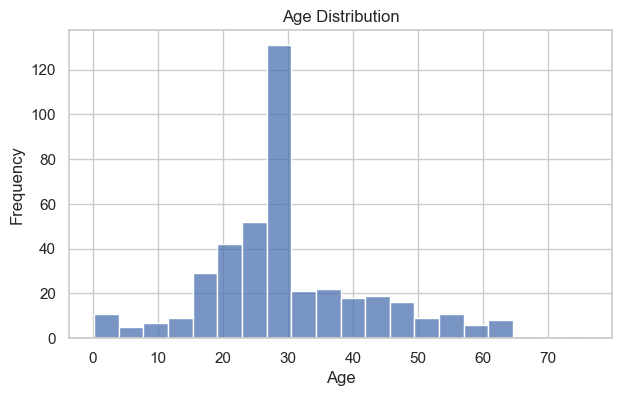

In [9]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="Age", bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## 6. KDE Plot

Use a KDE plot to see a smooth distribution curve.

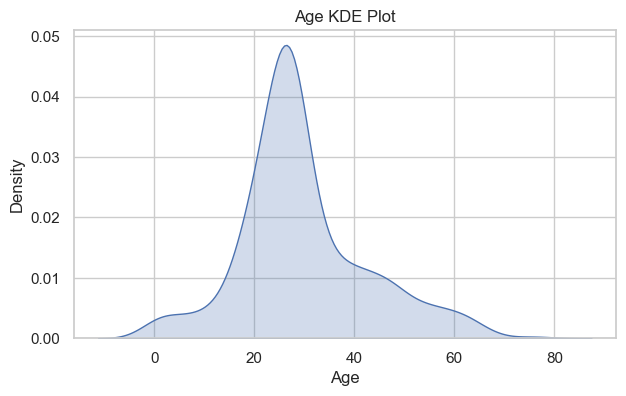

In [10]:
plt.figure(figsize=(7, 4))
sns.kdeplot(data=df, x="Age", fill=True)
plt.title("Age KDE Plot")
plt.xlabel("Age")
plt.show()

## 7. Box Plot

Use a box plot to compare spread, median, and outliers.

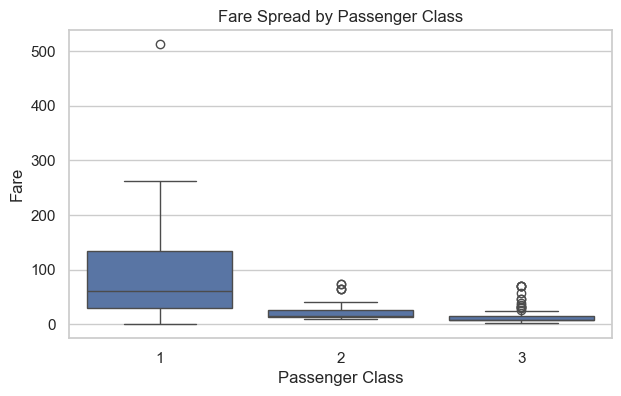

In [11]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Pclass", y="Fare")
plt.title("Fare Spread by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

## 8. Violin Plot

Use a violin plot to see spread plus distribution shape.

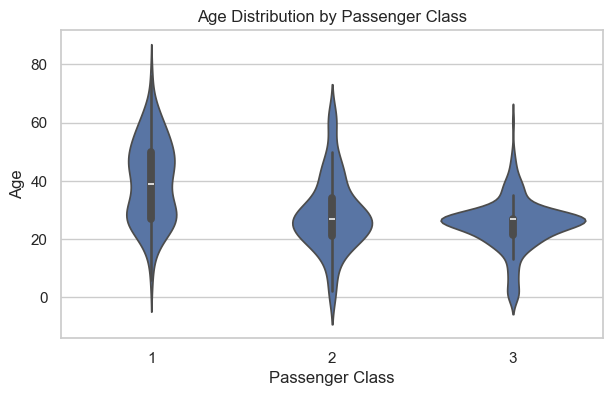

In [12]:
plt.figure(figsize=(7, 4))
sns.violinplot(data=df, x="Pclass", y="Age")
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

## 9. Strip Plot

Use a strip plot to show individual points for each category.

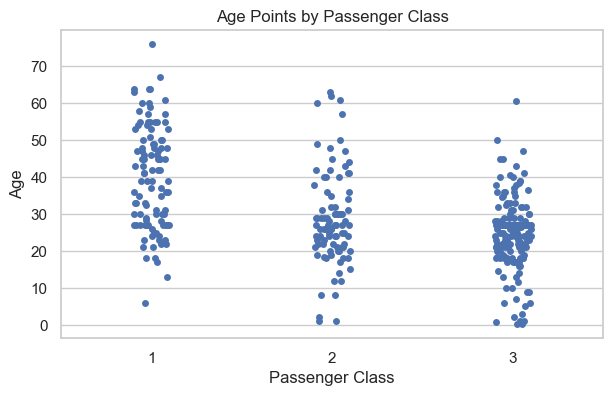

In [13]:
plt.figure(figsize=(7, 4))
sns.stripplot(data=df, x="Pclass", y="Age", jitter=True)
plt.title("Age Points by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

## 10. Swarm Plot

Use a swarm plot like a strip plot, but points are adjusted to avoid overlap.

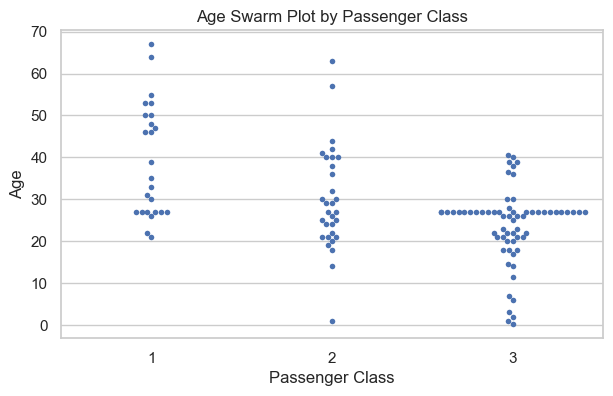

In [14]:
# Sample is used because swarm plots can become slow on large data.
sample_df = df.sample(n=min(120, len(df)), random_state=1)

plt.figure(figsize=(7, 4))
sns.swarmplot(data=sample_df, x="Pclass", y="Age", size=4)
plt.title("Age Swarm Plot by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

## 11. Scatter Plot

Use a scatter plot to check relation between two numeric columns. `hue` adds category color.

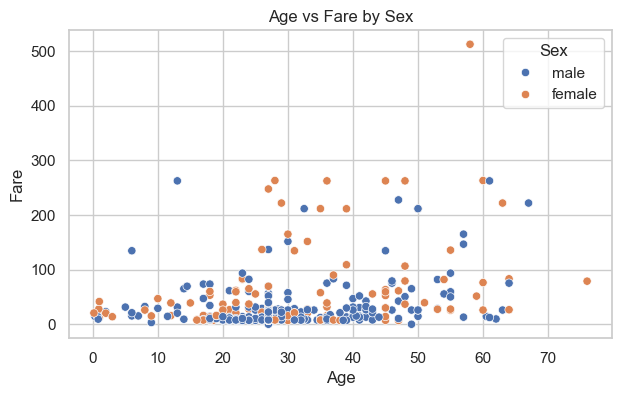

In [15]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x="Age", y="Fare", hue="Sex")
plt.title("Age vs Fare by Sex")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

## 12. Line Plot

Use a line plot to show trend or change.

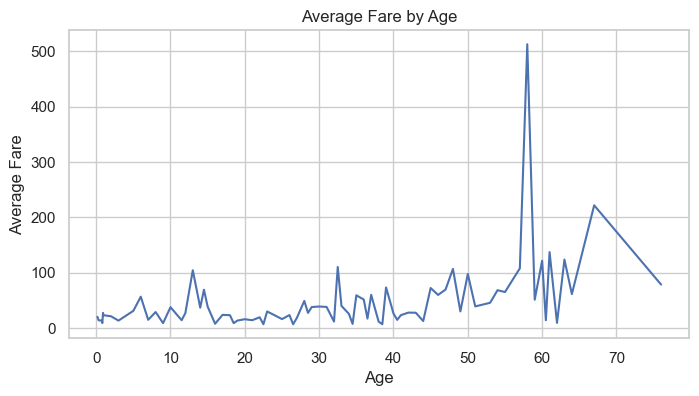

In [16]:
age_fare = df.groupby("Age", as_index=False)["Fare"].mean().sort_values("Age")

plt.figure(figsize=(8, 4))
sns.lineplot(data=age_fare, x="Age", y="Fare")
plt.title("Average Fare by Age")
plt.xlabel("Age")
plt.ylabel("Average Fare")
plt.show()

## 13. Regression Plot

Use a regression plot to show scatter points with a trend line.

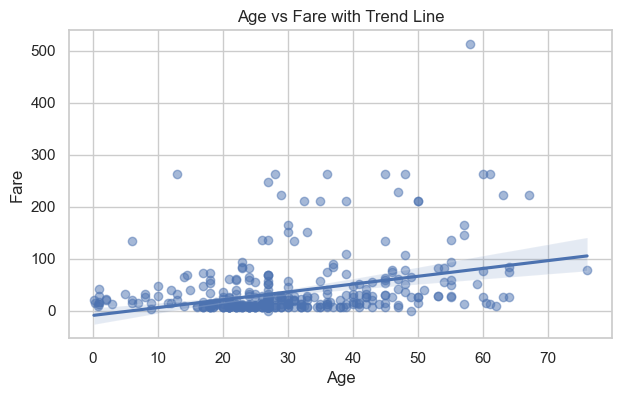

In [17]:
plt.figure(figsize=(7, 4))
sns.regplot(data=df, x="Age", y="Fare", scatter_kws={"alpha": 0.5})
plt.title("Age vs Fare with Trend Line")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

## 14. Seaborn Heatmap

Use a heatmap to show correlation or any matrix values.

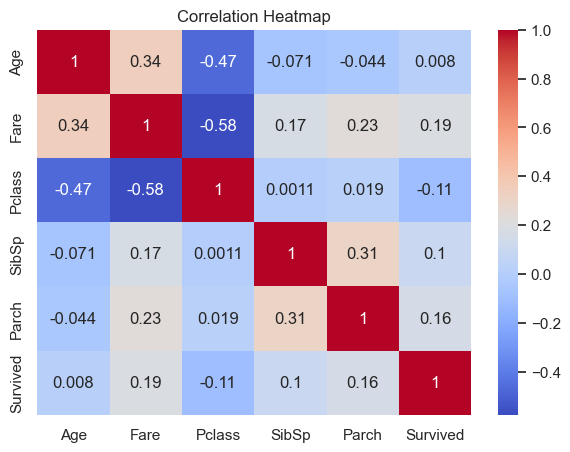

In [18]:
numeric_df = df[["Age", "Fare", "Pclass", "SibSp", "Parch", "Survived"]]
corr = numeric_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 15. Pair Plot

Use a pair plot to quickly compare multiple numeric columns.

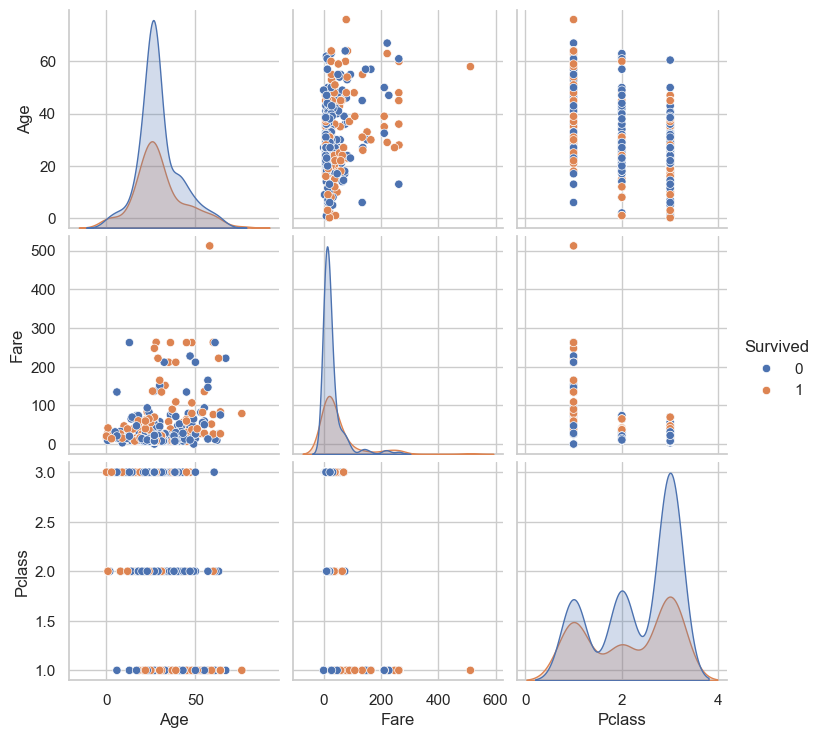

In [19]:
sns.pairplot(df[["Age", "Fare", "Pclass", "Survived"]].dropna(), hue="Survived")
plt.show()

## 16. Joint Plot

Use a joint plot to see scatter relation plus distributions.

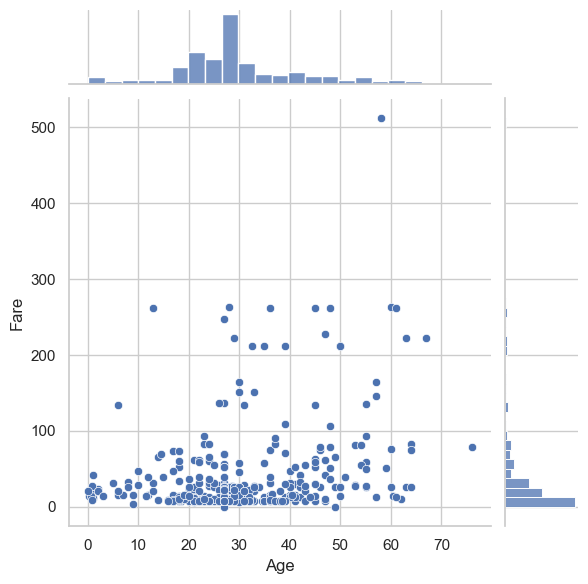

In [20]:
sns.jointplot(data=df, x="Age", y="Fare", kind="scatter", height=6)
plt.show()

## 17. Categorical Plot

Use `catplot` to create category-based charts. Change `kind` to `bar`, `box`, `violin`, `strip`, or `count`.

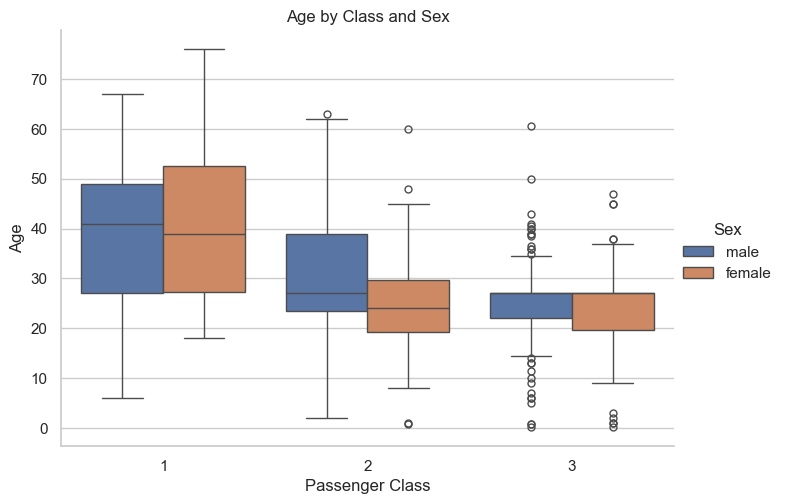

In [21]:
sns.catplot(data=df, x="Pclass", y="Age", hue="Sex", kind="box", height=5, aspect=1.4)
plt.title("Age by Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

## 18. Quick Revision Table

| Chart | Function | Best Use |
 |---|---|---|
 | Count Plot | `sns.countplot()` | Count category values |
 | Bar Plot | `sns.barplot()` | Compare average values |
 | Histogram | `sns.histplot()` | Numeric distribution |
 | KDE Plot | `sns.kdeplot()` | Smooth distribution |
 | Box Plot | `sns.boxplot()` | Spread and outliers |
 | Violin Plot | `sns.violinplot()` | Spread plus distribution shape |
 | Strip Plot | `sns.stripplot()` | Individual category points |
 | Swarm Plot | `sns.swarmplot()` | Non-overlapping category points |
 | Scatter Plot | `sns.scatterplot()` | Relation between two numbers |
 | Line Plot | `sns.lineplot()` | Trend or change |
 | Regression Plot | `sns.regplot()` | Scatter with trend line |
 | Heatmap | `sns.heatmap()` | Correlation or matrix values |
 | Pair Plot | `sns.pairplot()` | Compare many numeric columns |
 | Joint Plot | `sns.jointplot()` | Relation plus distributions |
 | Categorical Plot | `sns.catplot()` | Flexible category charts |